##### El objetivo fue identificar qué clientes tienen mayor probabilidad de aceptar un crédito, para optimizar la campaña de llamadas del banco.
##### Creamos un modelo XGBoost que predice la probabilidad de conversión de cada cliente, y usamos un threshold optimizado para equilibrar precisión y recall.

##### Por qué XGBoost:
##### - Maneja bien datos tabulares
##### - Captura relaciones no lineales
##### - Robusto ante desbalance

### **1. Carga y procesamiento de datos**

In [ ]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

### **2.Entrenamiento del modelo XGBoost**
##### Explicación simple de cómo funciona:
##### XGBoost construye múltiples árboles secuenciales, donde cada nuevo árbol corrige errores del anterior. La combinación final produce una probabilidad entre 0 y 1. 

In [2]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      7985
           1       0.57      0.30      0.39      1058

    accuracy                           0.89      9043
   macro avg       0.74      0.63      0.67      9043
weighted avg       0.87      0.89      0.88      9043

ROC AUC: 0.7924237079685089


### **3. Predicción y ajuste de threshold**
##### En vez de usar 0.5:
- Probamos múltiples thresholds
- Elegimos 0.31 porque maximiza F1
##### Explicación:
##### Ajustar el threshold permite equilibrar detección de clientes buenos y reducción de llamadas innecesarias.

In [3]:
thresholds = np.linspace(0,1,100)
f1_scores = []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    f1_scores.append(f1)

best_t = thresholds[np.argmax(f1_scores)]
print("Mejor threshold:", best_t)

Mejor threshold: 0.31313131313131315


In [4]:
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predicciones
y_pred = xgb_model.predict(X_test)
y_proba = xgb_model.predict_proba(X_test)[:, 1]

threshold = 0.31
y_pred_custom = (y_proba >= threshold).astype(int)

print(classification_report(y_test, y_pred_custom))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.93      0.93      0.93      7985
           1       0.47      0.49      0.48      1058

    accuracy                           0.88      9043
   macro avg       0.70      0.71      0.70      9043
weighted avg       0.88      0.88      0.88      9043

ROC AUC: 0.7924237079685089


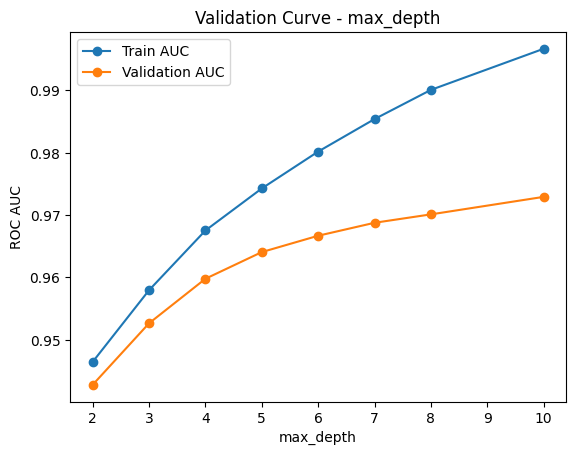

In [ ]:
# Valores a probar
param_range = [2, 3, 4, 5, 6, 7, 8, 10]

# Validation curve
train_scores, val_scores = validation_curve(
    xgb_model,
    X_train,
    y_train,
    param_name="max_depth",
    param_range=param_range,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Promedios
train_mean = np.mean(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)

# Gráfico
plt.figure()
plt.plot(param_range, train_mean, marker="o", label="Train AUC")
plt.plot(param_range, val_mean, marker="o", label="Validation AUC")
plt.xlabel("max_depth")
plt.ylabel("ROC AUC")
plt.title("Validation Curve - max_depth")
plt.legend()
plt.show()

### **4.Validación cruzada (Cross-validation)**

In [13]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Validación cruzada usando ROC AUC
cv_scores = cross_val_score(
    xgb_model,
    X_train,
    y_train,
    cv=skf,
    scoring="roc_auc",
    n_jobs=-1
)

print("ROC AUC por fold:", cv_scores)
print("ROC AUC promedio:", np.mean(cv_scores))

ROC AUC por fold: [0.97260231 0.9700323  0.97204686 0.97083987 0.97130865]
ROC AUC promedio: 0.9713659955041196


### **5. Lift / Top X% análisis**
##### Usamos: Lift Top 20% (impacto negocio)
##### Explicación: El modelo ordena correctamente a los clientes por probabilidad, permitiendo priorizar los más prometedores.

In [14]:
# Combinar probabilidades y etiquetas reales
df_eval = pd.DataFrame({
    "proba": y_proba,
    "real": y_test
})

# Definir top X%
top_percent = 20
cutoff = np.percentile(df_eval["proba"], 100-top_percent)

# Seleccionar top X%
top_clients = df_eval[df_eval["proba"] >= cutoff]

# Conversiones
conversion_general = df_eval["real"].mean()
conversion_top = top_clients["real"].mean()
lift = conversion_top / conversion_general

print(f"Promedio de conversión general: {conversion_general:.2%}")
print(f"Promedio de conversión Top {top_percent}%: {conversion_top:.2%}")
print(f"Lift Top {top_percent}%: {lift:.2f}x")

Promedio de conversión general: 11.70%
Promedio de conversión Top 20%: 35.10%
Lift Top 20%: 3.00x


### **6. Segmentación de clientes (Alta / Media / Baja)**
##### Convertimos probabilidades en:
- Alta → Top 20%
- Media → siguiente 30%
- Baja → resto
##### Eso traduce el modelo en decisiones reales.

In [17]:
p80 = np.percentile(y_proba, 80)
p50 = np.percentile(y_proba, 50)

def segmentar(prob):
    if prob >= np.percentile(y_proba, 80):
        return "Alta"
    elif prob >= np.percentile(y_proba, 50):
        return "Media"
    else:
        return "Baja"

df_eval["segmento"] = df_eval["proba"].apply(segmentar)

print("\n=== Distribución por segmento ===")
print(df_eval["segmento"].value_counts(normalize=True).map("{:.2%}".format))


=== Distribución por segmento ===
segmento
Baja     49.99%
Media    30.00%
Alta     20.00%
Name: proportion, dtype: str


### **7.Visualización / interpretación**

In [1]:
# Gráfico de distribución de segmentos
plt.figure(figsize=(6,4))
sns.countplot(data=df_eval, x="segmento", order=["Alta","Media","Baja"])
plt.title("Distribución de clientes por segmento")
plt.ylabel("Número de clientes")
plt.show()

NameError: name 'plt' is not defined

##### El modelo clasifica a los clientes en tres segmentos:
- Alta → top 20% de clientes con mayor probabilidad de conversión
- Media → siguiente 30%, clientes potenciales
- Baja → 50% restante, baja probabilidad

Esto nos permite enfocar recursos en los clientes que realmente importan.

##### Mensaje clave: “Llamando solo al segmento Alta, priorizamos los clientes más prometedores, maximizando eficiencia.”

In [ ]:
# Gráfico de lift por deciles
df_eval["decile"] = pd.qcut(df_eval["proba"], 10, labels=False)
lift_table = df_eval.groupby("decile")["real"].mean().sort_index(ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x=lift_table.index, y=lift_table.values)
plt.title("Lift por decil (decil 0 = top 10%)")
plt.ylabel("Tasa de conversión")
plt.xlabel("Decil (orden descendente de probabilidad)")
plt.show()

##### Mostrar gráfico de lift por deciles y resultado top 20%:
- Promedio de conversión general: ~11.7%
- Top 20% de clientes: 35.1%
- Lift Top 20% = 3x

##### Explicación:
##### “Si llamamos a todos los clientes, la conversión promedio es 11.7%. Pero si enfocamos la campaña en el top 20% según el modelo, la conversión sube a 35.1%, triplicando la efectividad. Esto demuestra que el modelo tiene impacto directo en negocio, sin necesidad de conocer costos exactos.”

### **8. Guardar modelo**

In [ ]:
model_xgboost = {
    "model": xgb_model,
    "threshold": threshold,
    "features": X_test.columns.tolist()
}
joblib.dump(model_xgboost, "../models/xgb_model.pkl")
print("\n✅ Modelo guardado en ../models/xgb_model.pkl")

### ------ OPTUNA VERSION ------

In [10]:
import optuna
import xgboost as xgb

# ── Cargar datos ──────────────────────────────────────────────
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

# ── Función objetivo ──────────────────────────────────────────
def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 1000),
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 1e-4, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "gamma":             trial.suggest_float("gamma", 0, 5),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 1.0, log=True),
        "random_state": 42,
        "eval_metric": "logloss",
    }

    model = xgb.XGBClassifier(**params)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1
    )
    return scores.mean()

# ── Ejecutar estudio ──────────────────────────────────────────
optuna.logging.set_verbosity(optuna.logging.WARNING)  # output limpio

study = optuna.create_study(
   direction="maximize",
   study_name="xgboost_optuna",
)

study.optimize(
   objective,
   n_trials=100,
   show_progress_bar=True
)

# ── Resultados ────────────────────────────────────────────────
print(f"\n✅ Mejor ROC-AUC (CV): {study.best_value:.4f}")
print(f"📌 Mejores parámetros:\n{study.best_params}")

# ── Entrenar modelo final con X_train completo ────────────────
best_model = xgb.XGBClassifier(
    **study.best_params,
    random_state=42,
    eval_metric="logloss",
)

best_model.fit(X_train, y_train)

# ── Evaluar en X_test ─────────────────────────────────────────
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
y_pred       = best_model.predict(X_test)

test_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\n🎯 ROC-AUC en test: {test_auc:.4f}")

Best trial: 11. Best value: 0.969701:  13%|█▎        | 13/100 [09:02<1:00:30, 41.73s/it]


[W 2026-03-05 14:36:40,180] Trial 13 failed with parameters: {'n_estimators': 985, 'max_depth': 9, 'learning_rate': 0.018919778144306745, 'subsample': 0.5033459552811891, 'colsample_bytree': 0.696686366106442, 'min_child_weight': 6, 'gamma': 1.1397529176400416, 'reg_alpha': 0.0020826165479148166, 'reg_lambda': 4.4973906031299533e-07} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\Coder\Documents\Proyectos-Modulo2\Proyecto6_Clasificacion_Equipo2\.venv\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\Coder\AppData\Local\Temp\ipykernel_22708\2247312442.py", line 29, in objective
    scores = cross_val_score(
             ^^^^^^^^^^^^^^^^
  File "c:\Users\Coder\Documents\Proyectos-Modulo2\Proyecto6_Clasificacion_Equipo2\.venv\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwa

KeyboardInterrupt: 